# Anchored Langevin on the multivariate Laplace: $J=0$, constant $J_a$ and state dependent $J_s$

Three schemes are compared throughout, under the labels used in the rest of the project:

* **$J=0$** — the reversible anchored scheme;
* **constant $J_a$, $a=\dots$** — the constant antisymmetric skew, $+a$ above the diagonal and $-a$ below
  (the tridiagonal pattern of the earlier notebooks), plus two *aimed* variants of the same construction;
* **state dependent $J_s$, $s=\dots$** — the field $J_s(x)=s\,[x]_\times$ of the ball-constrained study,
  $J_s(x)\,w=s\,(x\times w)$, run here without the ball.

Unconstrained, so there is no boundary condition and **every** constant antisymmetric $J$ leaves $\pi$
invariant — the extra flux is $J\nabla e^{-U_0}$ and $\nabla\!\cdot(J\nabla\varphi)=0$ for constant skew.
The same holds for $J_s$: $\nabla\!\cdot J_s=0$ is an algebraic identity of the cross-product matrix, so
the update carries no correction term. The choice of $J$ is therefore purely a *rate* choice, and the
question is which one to make.

## Which multivariate Laplace?

"Multivariate Laplace" names more than one distribution, and the difference is exactly what this project
cares about — *where the potential fails to be differentiable*. Both are run below. Write
$\Sigma=LL^\top$ and $M=L^{-1}$.

| | potential $U(x)$ | non-differentiable set | exact sampling |
|---|---|---|---|
| **Target A** — elliptical Laplace | $\lVert Mx\rVert_2$ | the single point $\{0\}$ | $x=L\,r\,u$, $r\sim\mathrm{Gamma}(d,1)$, $u$ uniform on $S^{d-1}$ |
| **Target B** — correlated $\ell_1$ Laplace | $\lVert Mx\rVert_1$ | $d$ hyperplanes $\{(Mx)_i=0\}$ | $x=Ly$, $y_i\sim\mathrm{Laplace}(0,1)$ |

Target A's kink sits at a single point the chain essentially never visits — a *weak* test of
non-smoothness. Target B keeps the kinks on a set the chain crosses constantly. Neither factorises.

$\Sigma=DCD$ with $D=\mathrm{diag}(0.5,1,2)$ and $C$ equicorrelation, $\rho=0.6$.

## Dynamics

$$dX_t=-\bigl(I+J(X_t)\bigr)\,\nabla U_0(X_t)\,e^{\Delta(X_t)}\,dt+\sqrt2\,e^{\Delta(X_t)/2}\,dW_t,\qquad\Delta=U-U_0,$$

with $J(x)\equiv0$, $J(x)\equiv J_a$ constant, or $J(x)=J_s(x)=s\,[x]_\times$,

with the anchor rounding off the kink. $\Delta\le0$ and bounded below, so $e^{\Delta}$ needs no clamping,
and $\nabla U$ is never evaluated.

---

## What changed

**The settings text and the code disagreed.** The prose said $\eta=5\times10^{-3}$ over 2000 iterations;
the code ran $\eta=6\times10^{-3}$ for 1500. The code is now the only source of these numbers and they are
printed below.

**Nothing had converged at the reporting horizon.** At 1500 iterations $J=0$ sits at mean $W_1=0.331$
against a floor of $0.064$ — five times above it, and still falling. It needs roughly 9000. Everything
here runs to 12000, and speed is reported as $\tau$, the iteration after which $W_1$ stays below twice the
floor, separately from stationary accuracy.

**Replicas and intervals.** Every number is 6 replicas with a bootstrap interval, run as one batched
ensemble.

**The state dependent field is run alongside the constant one.** The companion ball-constrained study
compared $J=0$ against $J_s(x)=s\,[x]_\times$; that field is added here so the three families share one
set of axes. Note $\lVert J_s(x)\rVert_2=s\lVert x\rVert$, so unconstrained its strength is unbounded in
the tails and $s$ has to be far smaller than on the ball.

**The skew was pointed in an arbitrary direction.** $J_a$ is tridiagonal — a fixed pattern with no
relation to $\Sigma$. Since unconstrained the axis is free, it can instead be put in the plane of the two
largest-variance eigenvectors, which is where the sampler actually crawls. That turns out to be most of
the available gain.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# -----------------------------
# Settings -- the only place these live
# -----------------------------
d        = 3
N        = 5000        # walkers per replica
REPLICAS = 6
MAXIT    = 12000       # long enough that J = 0 reaches the floor; 1500 was not
eta      = 6e-3
delta    = 0.2         # anchor smoothing
x_start  = 0.3
SEED     = 1006
TRACK    = 25
A_LIST   = [2.0, 4.0, 8.0]   # strengths of the aligned constant J_a
A_MAIN   = 4.0               # constant J_a strength in the headline figures
S_LIST   = [0.5, 1.0, 2.0, 5.0]   # strengths of the state dependent J_s;  ||J_s(x)|| = s ||x||
S_MAIN   = 1.0               # state dependent J_s strength in the headline figures
TAU_MULT = 3.0         # tau threshold, as a multiple of the floor.  2x sat inside the
                       # stationary noise of the slower schemes and made tau unmeasurable.

SCALES, RHO = [0.5, 1.0, 2.0], 0.6


def make_L(dim, scales, rho):
    D = np.diag(scales)
    C = np.full((dim, dim), rho)
    np.fill_diagonal(C, 1.0)
    return np.linalg.cholesky(D @ C @ D)


L3 = make_L(d, SCALES, RHO)
SIG = L3 @ L3.T
Minv = torch.tensor(np.linalg.inv(L3))
EVAL, EVEC = np.linalg.eigh(SIG)
print("Sigma =\n", np.round(SIG, 3))
print("eigenvalues", np.round(EVAL, 3), "  condition number {:.1f}".format(EVAL[-1] / EVAL[0]))
print("\neta = {:g}, {} iterations, N = {} x {} replicas".format(eta, MAXIT, N, REPLICAS))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]
eigenvalues [0.131 0.595 4.525]   condition number 34.6

eta = 0.006, 12000 iterations, N = 5000 x 6 replicas


## The constant skews $J_a$, and the state dependent $J_s$

All are constant and antisymmetric, so all leave $\pi$ invariant; they differ only in which plane they
rotate.

* `tridiagonal` — the original **constant $J_a$**: $+a$ above the diagonal, $-a$ below. A fixed pattern,
  unrelated to $\Sigma$. This is what the label *constant $J_a$, a = …* refers to below.
* `aligned` — rotation in the plane of the two **largest-variance** eigenvectors of $\Sigma$, the
  directions along which the reversible dynamics crawls.
* `anti-aligned` — the same construction in the plane of the two **smallest**, as a control.

Each is normalised to unit spectral norm before scaling by $a$, so $a$ means the same push for all three.

The **state dependent $J_s$** is not a matrix but a field,

$$J_s(x)=s\,[x]_\times=\begin{pmatrix}0&-s x_3& s x_2\\ s x_3&0&-s x_1\\ -s x_2& s x_1&0\end{pmatrix},
\qquad J_s(x)\,w=s\,(x\times w),$$

antisymmetric at every $x$ with $\nabla\!\cdot J_s=0$, so it also leaves $\pi$ invariant with no
correction term. Its drift is tangential to every sphere about the origin, and its strength
$\lVert J_s(x)\rVert_2=s\lVert x\rVert$ grows with the state.

In [3]:
def J_tridiagonal(dim, a):
    J = (torch.diag(torch.ones(dim - 1), diagonal=1)
         - torch.diag(torch.ones(dim - 1), diagonal=-1))
    return a * J / torch.linalg.matrix_norm(J, ord=2)


def J_plane(u, v, a):
    """Generator of rotation in span(u, v), unit spectral norm, scaled by a."""
    A = np.outer(np.asarray(u, float), np.asarray(v, float))
    A = A - A.T
    return torch.tensor(a * A / np.linalg.norm(A, 2))


def J_state(s):
    """State dependent skew J_s(x) = s [x]_x, returned as the map (x, w) -> J_s(x) w = s (x cross w)."""
    def apply(x, w):
        return s * torch.cross(x, w, dim=1)
    apply.s = s
    return apply


def J_aligned(a):
    return J_plane(EVEC[:, 2], EVEC[:, 1], a)       # two largest variances


def J_antialigned(a):
    return J_plane(EVEC[:, 0], EVEC[:, 1], a)       # two smallest


rows = []
for name, fn in [("tridiagonal", J_tridiagonal_a := (lambda a: J_tridiagonal(d, a))),
                 ("aligned", J_aligned), ("anti-aligned", J_antialigned)]:
    J = fn(4.0)
    rows.append({"skew": name,
                 "max |J + J^T|": "{:.1e}".format(float((J + J.T).abs().max())),
                 "||J||_2 at a=4": round(float(torch.linalg.matrix_norm(J, ord=2)), 3),
                 "rotates in": {"tridiagonal": "fixed pattern",
                                "aligned": "plane of the 2 largest variances",
                                "anti-aligned": "plane of the 2 smallest"}[name]})
pd.DataFrame(rows).set_index("skew")

,max |J + J^T|,||J||_2 at a=4,rotates in
skew,,,
tridiagonal,0.0e+00,4.0,fixed pattern
aligned,0.0e+00,4.0,plane of the 2 largest variances
anti-aligned,0.0e+00,4.0,plane of the 2 smallest


In [4]:
# -----------------------------
# Targets.  U is never differentiated; only U0 is.
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0


def sample_target(kind, size, rng):
    """Exact draws -- no rejection needed for either target."""
    if kind == "ell":
        r = rng.gamma(d, 1.0, size)
        u = rng.normal(size=(size, d))
        u /= np.linalg.norm(u, axis=1, keepdims=True)
        y = r[:, None] * u
    else:
        y = rng.laplace(0.0, 1.0, size=(size, d))
    return y @ L3.T


def w1_floor_per_coord(kind, size, rng, n_pairs=24):
    """W1 between two INDEPENDENT size-`size` draws, averaged over `n_pairs` fresh pairs.

    Averaging against one fixed reference is not enough: that estimator carries the
    particular reference's own deviation, and its spread across independent estimates is
    15-20% per coordinate -- on Target B a low draw put the tau threshold only 1.65x above
    the converged plateau, which turns tau into a last-crossing lottery.  Drawing both
    sides fresh each time removes the conditioning and brings the spread to a few percent.
    """
    out = np.zeros((n_pairs, d))
    for k in range(n_pairs):
        a, b = sample_target(kind, size, rng), sample_target(kind, size, rng)
        out[k] = [wasserstein_distance(a[:, i], b[:, i]) for i in range(d)]
    return out.mean(axis=0)


@torch.no_grad()
def run_replicas(kind, J, ref, S=REPLICAS, n_steps=MAXIT, seed=SEED, eta=eta):
    """J is a constant antisymmetric matrix, or a callable (x, g) -> J_s(x) g for a state dependent skew.

    Returns (iters, mean-over-coords W1 [S, ntrack], per-coord W1 [ntrack, d], X [S,N,d])."""
    U, U0, gU0 = build_target(kind)
    state_dep = callable(J)                    # J_s(x): a map (x, g) -> J_s(x) g
    Mj = None if state_dep else (torch.eye(d) + J).T
    torch.manual_seed(seed)
    x = torch.full((S * N, d), x_start)
    it, W, Wc = [], [], []
    for k in range(n_steps):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        drift = g + J(x, g) if state_dep else g @ Mj          # (I + J(x)) grad U0 e^Delta
        x = x - eta * drift + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x)
        if not torch.isfinite(x).all():
            # ||J_s(x)|| = s||x|| is unbounded without the ball; if the Euler step overflows there is
            # nothing left to measure, so stop and say so rather than let a NaN take out the notebook
            print("      !! non-finite state at iteration {} -- chain diverged; W1 is tracked up to here"
                  .format(k + 1), flush=True)
            break
        if (k + 1) % TRACK == 0:
            xn = x.numpy().reshape(S, N, d)
            per = np.array([[wasserstein_distance(ref[:, i], xn[r, :, i]) for i in range(d)]
                            for r in range(S)])
            it.append(k + 1)
            W.append(per.mean(axis=1))
            Wc.append(per.mean(axis=0))
    return np.array(it), np.array(W).T, np.array(Wc), x.numpy().reshape(S, N, d)


def tau_one(it, w, thr):
    bad = np.where(w > thr)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return float(it[j]) if j < len(it) else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
             if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def boot_speedup(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            draws.append(np.nanmean(a) / np.nanmean(b))
    return (np.nanmean(base) / np.nanmean(cur),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


def fmt_tau(t):
    return "never" if not np.isfinite(t[0]) else "{:.0f} [{:.0f}, {:.0f}]".format(*t)


def fmt_w1(st):
    """A diverged chain has W1 in the 1e2 .. 1e100 range; keep those readable."""
    if st[0] < 100:
        return "{:.4f} [{:.4f}, {:.4f}]".format(*st)
    return "{:.3g} [{:.3g}, {:.3g}]".format(*st)


def fmt_ratio(x):
    return "{:.2f}x".format(x) if x < 100 else "{:.3g}x".format(x)


def fmt_speed(sp):
    return "never reaches it" if not np.isfinite(sp[0]) else "{:.2f}x [{:.2f}, {:.2f}]".format(*sp)


def tau_is_resolvable(stat_mean, floor_mean, margin=1.5):
    """tau only means something if the scheme settles well below the threshold; otherwise
    the curve wanders across it and the last crossing is noise."""
    return stat_mean * margin < TAU_MULT * floor_mean


# the anchor gap is bounded, so exp(Delta) is safe without clamping
rows = []
for kind in ("ell", "l1"):
    U, U0, _ = build_target(kind)
    xs = torch.tensor(sample_target(kind, 4000, np.random.default_rng(0)))
    D = U(xs) - U0(xs)
    rows.append({"target": kind, "min Delta": round(float(D.min()), 4),
                 "max Delta": round(float(D.max()), 4),
                 "min exp(Delta)": round(float(D.exp().min()), 4)})
pd.DataFrame(rows).set_index("target")

,min Delta,max Delta,min exp(Delta)
target,,,
ell,-0.0974,-0.0017,0.9072
l1,-0.5039,-0.0143,0.6042


## Runs

In [5]:
TARGETS = {"ell": "Target A: elliptical Laplace", "l1": "Target B: correlated $\\ell_1$ Laplace"}

# Labels: "J = 0", "constant J_a, a = ..." and "state dependent J_s, s = ..." -- the three families of
# the project.  The aimed variants of the constant skew carry the same "constant J_a" prefix.
LAB_J0    = "J = 0"
def lab_Ja(a, how=""):   return "constant $J_a${}, a = {:g}".format(" " + how if how else "", a)
def lab_Js(s):           return "state dependent $J_s$, s = {:g}".format(s)

GRID = ([(LAB_J0, torch.zeros(d, d))]
        + [(lab_Ja(a), J_tridiagonal(d, a)) for a in (4.0, 8.0)]
        + [(lab_Ja(a, "aligned"), J_aligned(a)) for a in A_LIST]
        + [(lab_Ja(4.0, "anti-aligned"), J_antialigned(4.0))]
        + [(lab_Js(s), J_state(s)) for s in S_LIST])

rng = np.random.default_rng(SEED)
refs, floors, RES = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor_per_coord(kind, N, rng)
    RES[kind] = {}
    print("\n### {}   per-coordinate floor {}   mean {:.4f}".format(
        kind, np.round(floors[kind], 4), floors[kind].mean()), flush=True)
    for lab, J in GRID:
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, J, refs[kind])
        RES[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X,
                          "taus": np.array([tau_one(it, w, TAU_MULT * floors[kind].mean()) for w in W]),
                          "stat": W[:, -20:].mean(axis=1)}
        print("   {:<34} {:5.0f}s".format(lab.replace("$", ""), time.time() - t0), flush=True)

MAIN = [LAB_J0, lab_Ja(A_MAIN), lab_Js(S_MAIN)]
COL = {LAB_J0: "#C44E52", lab_Ja(A_MAIN): "#4C72B0", lab_Js(S_MAIN): "#55A868",
       lab_Ja(A_MAIN, "aligned"): "#DD8452"}


### ell   per-coordinate floor [0.0292 0.0526 0.127 ]   mean 0.0696


   J = 0                                 49s


   constant J_a, a = 4                   48s


   constant J_a, a = 8                   48s


   constant J_a aligned, a = 2           47s


...

   state dependent J_s, s = 0.5          53s


   state dependent J_s, s = 1            51s


   state dependent J_s, s = 2            52s


      !! non-finite state at iteration 10615 -- chain diverged; W1 is tracked up to here


   state dependent J_s, s = 5            44s


## Experiment 1 — the mean Wasserstein

$W_1$ averaged over the three coordinates, against iteration. This is the headline curve: one number per
scheme per iteration, so the schemes can be ranked without reading three panels at once. The three curves
are $J=0$, the constant $J_a$ at $a=4$ and the state dependent $J_s$ at $s=1$. Bands are the
5-95% range across the 6 replicas; the dotted line is the sampling floor and the dashed line is the
$\tau$ threshold.

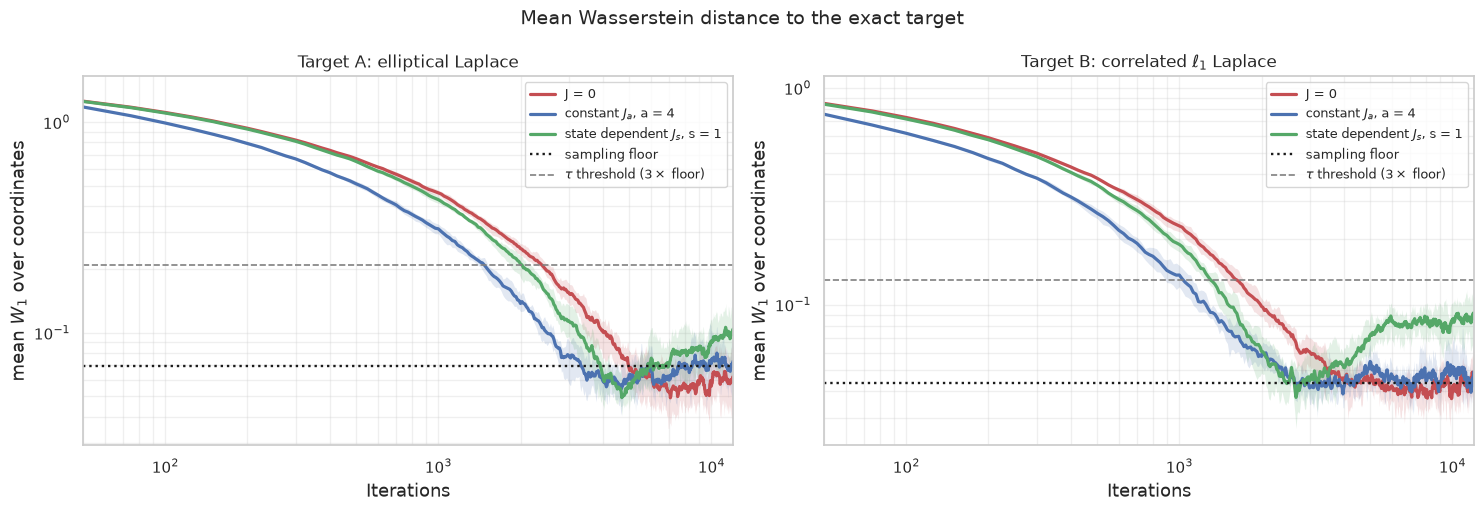

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, kind in zip(axes, TARGETS):
    for lab in MAIN:
        r = RES[kind][lab]
        ax.plot(r["it"], r["W"].mean(axis=0), linewidth=2.3, color=COL[lab], label=lab)
        ax.fill_between(r["it"], np.percentile(r["W"], 5, axis=0),
                        np.percentile(r["W"], 95, axis=0), color=COL[lab], alpha=0.16, linewidth=0)
    fl = floors[kind].mean()
    ax.axhline(fl, color="k", linestyle=":", linewidth=1.7, label="sampling floor")
    ax.axhline(TAU_MULT * fl, color="0.5", linestyle="--", linewidth=1.2,
               label=r"$\tau$ threshold ($3\times$ floor)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(50, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$ over coordinates", fontsize=13)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)
fig.suptitle("Mean Wasserstein distance to the exact target", fontsize=14)
plt.tight_layout()
plt.savefig("figures/mv_w1_mean.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 2 — component-wise

The same runs, split by coordinate. The mean above is dominated by coordinate 3, which has four times the
variance of coordinate 1 and mixes slowest; the per-coordinate view shows where the skew is actually
buying anything.

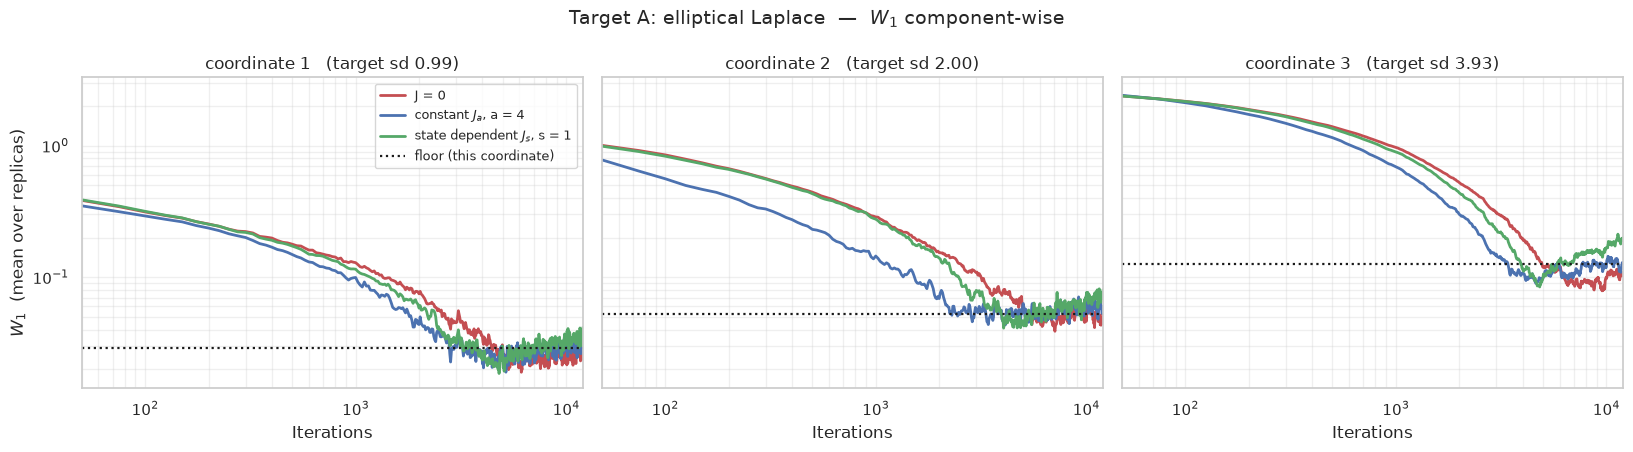

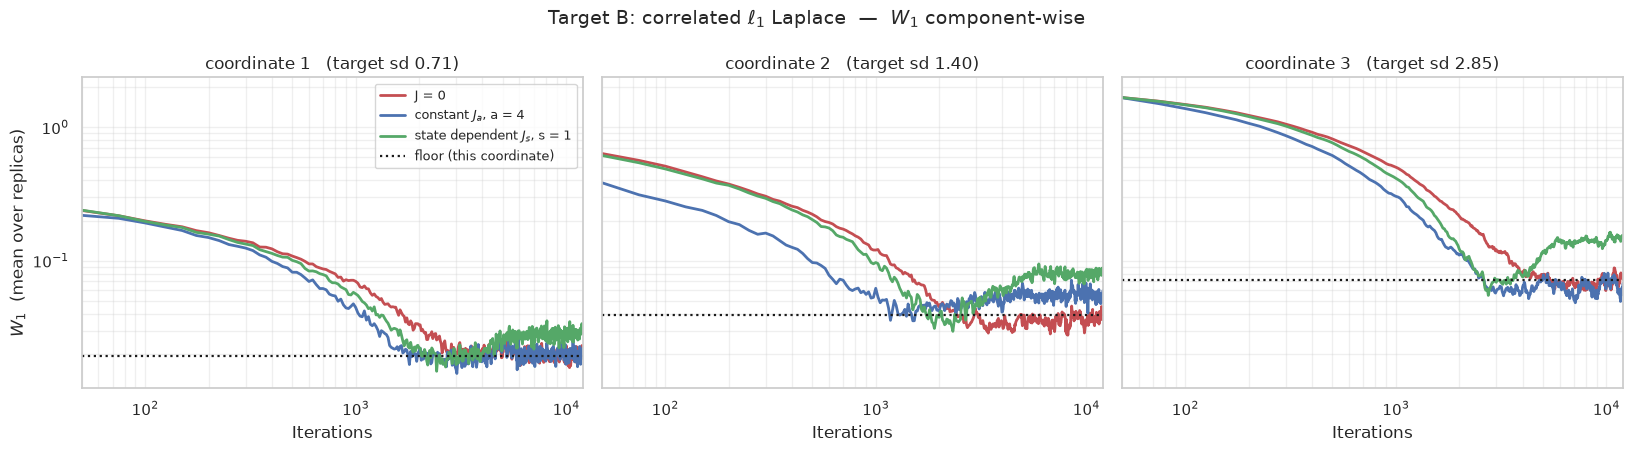

In [7]:
for kind in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6), sharey=True)
    for i, ax in enumerate(axes):
        for lab in MAIN:
            r = RES[kind][lab]
            ax.plot(r["it"], r["Wc"][:, i], linewidth=2, color=COL[lab], label=lab)
        ax.axhline(floors[kind][i], color="k", linestyle=":", linewidth=1.6,
                   label="floor (this coordinate)")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(50, MAXIT)
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_title("coordinate {}   (target sd {:.2f})".format(i + 1, refs[kind][:, i].std()),
                     fontsize=12)
        ax.grid(alpha=0.3, which="both")
    axes[0].set_ylabel(r"$W_1$  (mean over replicas)", fontsize=12)
    axes[0].legend(fontsize=9)
    fig.suptitle(TARGETS[kind] + r"  —  $W_1$ component-wise", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/mv_w1_percoord_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — aiming the rotation

In [8]:
rows = []
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    for lab in [lab_Ja(4.0, "aligned"), lab_Ja(4.0), lab_Ja(4.0, "anti-aligned")]:
        r = RES[kind][lab]
        rows.append({"target": kind, "skew at a = 4": lab.replace("$", "").split(",")[0],
                     "tau": fmt_tau(boot(r["taus"])),
                     "speed-up vs J = 0": fmt_speed(boot_speedup(base, r["taus"])),
                     "stationary W1": fmt_w1(boot(r["stat"])),
                     "floor": round(floors[kind].mean(), 4)})
display(pd.DataFrame(rows).set_index(["target", "skew at a = 4"]))
print("Same strength, same invariant law -- only the rotation plane differs.")

tau   speed-up vs J = 0  \
target skew at a = 4                                                      
ell    constant J_a aligned          775 [746, 808]  3.18x [3.02, 3.34]   
       constant J_a               1479 [1438, 1521]  1.66x [1.59, 1.74]   
       constant J_a anti-aligned  2229 [2100, 2362]  1.10x [1.03, 1.19]   
l1     constant J_a aligned          479 [446, 517]  3.41x [3.12, 3.73]   
       constant J_a                1033 [967, 1096]  1.58x [1.46, 1.72]   
       constant J_a anti-aligned  1475 [1412, 1533]  1.11x [1.04, 1.18]   

                                            stationary W1   floor  
target skew at a = 4                                               
ell    constant J_a aligned       0.0673 [0.0584, 0.0753]  0.0696  
       constant J_a               0.0688 [0.0595, 0.0766]  0.0696  
       constant J_a anti-aligned  0.0705 [0.0568, 0.0842]  0.0696  
l1     constant J_a aligned       0.0430 [0.0412, 0.0447]  0.0434  
       constant J_a               0.0440 [0.0413, 0.0474]  0.0434  
       constant J_a anti-aligned  0.0527 [0.0491, 0.0562]  0.0434

Same strength, same invariant law -- only the rotation plane differs.


## Experiment 4 — strength, and the stepsize it needs

All schemes in the grid: $J=0$, the constant $J_a$ (tridiagonal, aligned and anti-aligned) and the state
dependent $J_s$.

$a$ cannot be raised indefinitely at fixed $\eta$: the drift is $(I+aJ)\nabla U_0$, so its magnitude grows
with $a$ and the Euler step eventually stops resolving it. For the state dependent field the same limit
arrives sooner, since $\lVert J_s(x)\rVert=s\lVert x\rVert$ is largest exactly where the walkers are
furthest out. The speed-up and the stationary error have to be
read together.

In [9]:
rows = []
for kind in TARGETS:
    base = RES[kind][LAB_J0]["taus"]
    fl = floors[kind].mean()
    for lab, _ in GRID:
        r = RES[kind][lab]
        st = boot(r["stat"])
        rows.append({"target": kind, "scheme": lab.replace("$", ""),
                     "tau": fmt_tau(boot(r["taus"])),
                     "speed-up": "--" if lab == LAB_J0 else fmt_speed(boot_speedup(base, r["taus"])),
                     "stationary W1": fmt_w1(st),
                     "vs floor": fmt_ratio(st[0] / fl),
                     "tau resolvable": "yes" if tau_is_resolvable(st[0], fl) else "NO"})
display(pd.DataFrame(rows).set_index(["target", "scheme"]))
print("floor: " + ", ".join("{} {:.4f}".format(k, floors[k].mean()) for k in TARGETS))

tau  \
target scheme                                                
ell    J = 0                             2462 [2388, 2550]   
       constant J_a, a = 4               1479 [1438, 1521]   
       constant J_a, a = 8               1333 [1262, 1408]   
       constant J_a aligned, a = 2       1033 [1000, 1067]   
       constant J_a aligned, a = 4          775 [746, 808]   
       constant J_a aligned, a = 8          667 [654, 683]   
       constant J_a anti-aligned, a = 4  2229 [2100, 2362]   
       state dependent J_s, s = 0.5      2238 [2154, 2308]   
       state dependent J_s, s = 1        2062 [1950, 2167]   
       state dependent J_s, s = 2                    never   
       state dependent J_s, s = 5                    never   
l1     J = 0                             1633 [1550, 1712]   
       constant J_a, a = 4                1033 [967, 1096]   
       constant J_a, a = 8                2596 [958, 5767]   
       constant J_a aligned, a = 2          662 [642, 683]   
       constant J_a aligned, a = 4          479 [446, 517]   
       constant J_a aligned, a = 8          358 [350, 367]   
       constant J_a anti-aligned, a = 4  1475 [1412, 1533]   
       state dependent J_s, s = 0.5      1533 [1467, 1600]   
       state dependent J_s, s = 1        1338 [1288, 1396]   
       state dependent J_s, s = 2                    never   
       state dependent J_s, s = 5                    never   

                                                   speed-up  \
target scheme                                                 
ell    J = 0                                             --   
       constant J_a, a = 4               1.66x [1.59, 1.74]   
       constant J_a, a = 8               1.85x [1.73, 1.97]   
       constant J_a aligned, a = 2       2.38x [2.28, 2.50]   
       constant J_a aligned, a = 4       3.18x [3.02, 3.34]   
       constant J_a aligned, a = 8       3.69x [3.55, 3.85]   
       constant J_a anti-aligned, a = 4  1.10x [1.03, 1.19]   
       state dependent J_s, s = 0.5      1.10x [1.05, 1.16]   
       state dependent J_s, s = 1        1.19x [1.12, 1.28]   
       state dependent J_s, s = 2          never reaches it   
       state dependent J_s, s = 5          never reaches it   
l1     J = 0                                             --   
       constant J_a, a = 4               1.58x [1.46, 1.72]   
       constant J_a, a = 8               0.63x [0.28, 1.73]   
       constant J_a aligned, a = 2       2.47x [2.32, 2.61]   
       constant J_a aligned, a = 4       3.41x [3.12, 3.73]   
       constant J_a aligned, a = 8       4.56x [4.28, 4.82]   
       constant J_a anti-aligned, a = 4  1.11x [1.04, 1.18]   
       state dependent J_s, s = 0.5      1.07x [0.99, 1.14]   
       state dependent J_s, s = 1        1.22x [1.14, 1.30]   
       state dependent J_s, s = 2          never reaches it   
       state dependent J_s, s = 5          never reaches it   

                                                        stationary W1  \
target scheme                                                           
ell    J = 0                                  0.0590 [0.0476, 0.0721]   
       constant J_a, a = 4                    0.0688 [0.0595, 0.0766]   
       constant J_a, a = 8                    0.1133 [0.1031, 0.1248]   
       constant J_a aligned, a = 2            0.0578 [0.0500, 0.0672]   
       constant J_a aligned, a = 4            0.0673 [0.0584, 0.0753]   
       constant J_a aligned, a = 8            0.0862 [0.0804, 0.0933]   
       constant J_a anti-aligned, a = 4       0.0705 [0.0568, 0.0842]   
       state dependent J_s, s = 0.5           0.0647 [0.0512, 0.0789]   
       state dependent J_s, s = 1             0.0994 [0.0795, 0.1183]   
       state dependent J_s, s = 2             0.4555 [0.4264, 0.4845]   
       state dependent J_s, s = 5        1.5e+03 [1.48e+03, 1.51e+03]   
l1     J = 0                                  0.0452 [0.0402, 0.0512]   
       constant J_a, a = 4     

floor: ell 0.0696, l1 0.0434


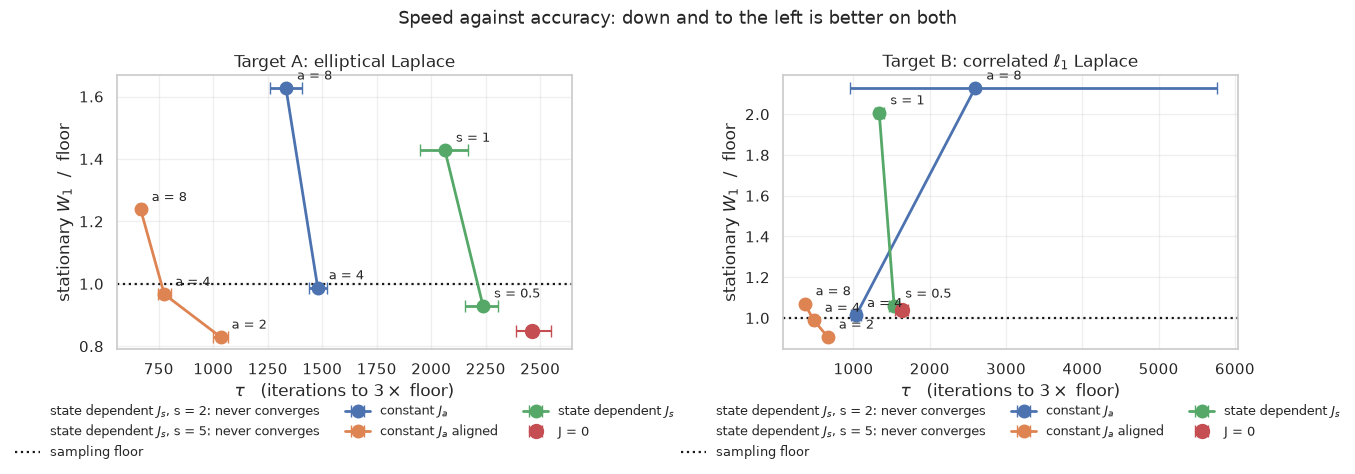

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, kind in zip(axes, TARGETS):
    base = RES[kind][LAB_J0]["taus"]
    fl = floors[kind].mean()
    for name, labs, c, par in [("constant $J_a$", [lab_Ja(a) for a in (4.0, 8.0)], "#4C72B0", "a"),
                               ("constant $J_a$ aligned", [lab_Ja(a, "aligned") for a in A_LIST], "#DD8452", "a"),
                               ("state dependent $J_s$", [lab_Js(s) for s in S_LIST], "#55A868", "s")]:
        xs_ = [float(l.split(par + " = ")[1]) for l in labs]
        tm = [boot(RES[kind][l]["taus"]) for l in labs]
        st = [boot(RES[kind][l]["stat"])[0] / fl for l in labs]
        ok = [i for i, v in enumerate(tm) if np.isfinite(v[0])]
        ax.errorbar([tm[i][0] for i in ok], [st[i] for i in ok],
                    xerr=[[tm[i][0] - tm[i][1] for i in ok], [tm[i][2] - tm[i][0] for i in ok]],
                    fmt="o-", color=c, capsize=4, linewidth=2, markersize=9, label=name)
        for i in ok:
            ax.annotate("{} = {:g}".format(par, xs_[i]), (tm[i][0], st[i]),
                        textcoords="offset points", xytext=(8, 6), fontsize=9)
        for i, v in enumerate(tm):
            if not np.isfinite(v[0]):       # off the chart: say so in the legend
                ax.plot([], [], " ", label="{}, {} = {:g}: never converges".format(name, par, xs_[i]))
    j0 = boot(RES[kind][LAB_J0]["taus"])
    ax.errorbar([j0[0]], [boot(RES[kind][LAB_J0]["stat"])[0] / fl],
                xerr=[[j0[0] - j0[1]], [j0[2] - j0[0]]], fmt="o", color="#C44E52",
                capsize=4, markersize=10, label=LAB_J0)
    ax.axhline(1.0, color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xlabel(r"$\tau$   (iterations to $3\times$ floor)", fontsize=12)
    ax.set_ylabel(r"stationary $W_1$  /  floor", fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
fig.suptitle("Speed against accuracy: down and to the left is better on both", fontsize=13)
plt.tight_layout()
plt.savefig("figures/mv_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()

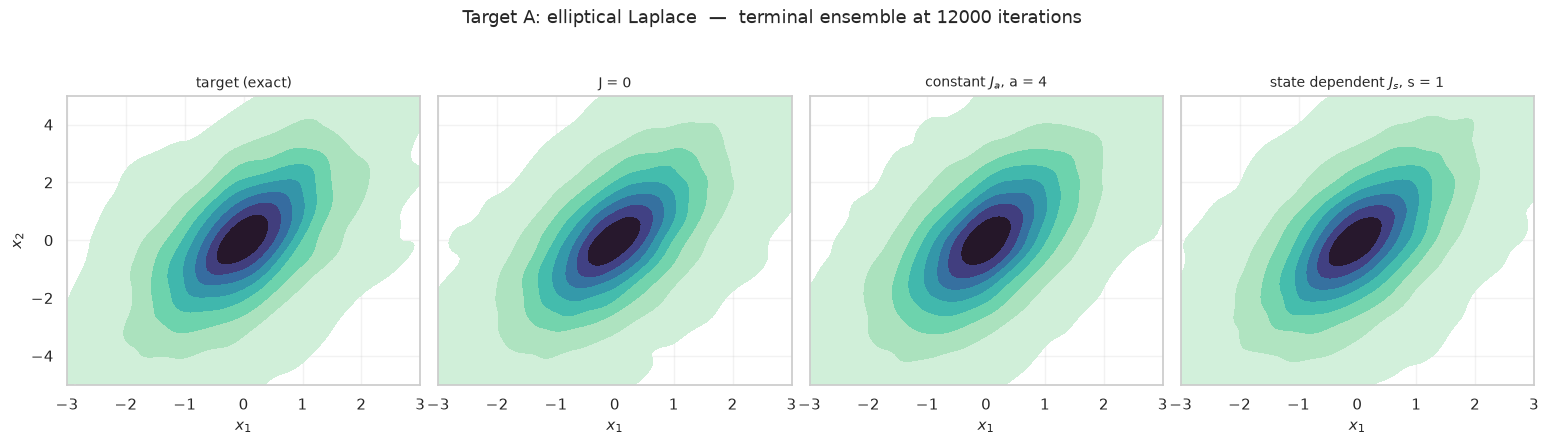

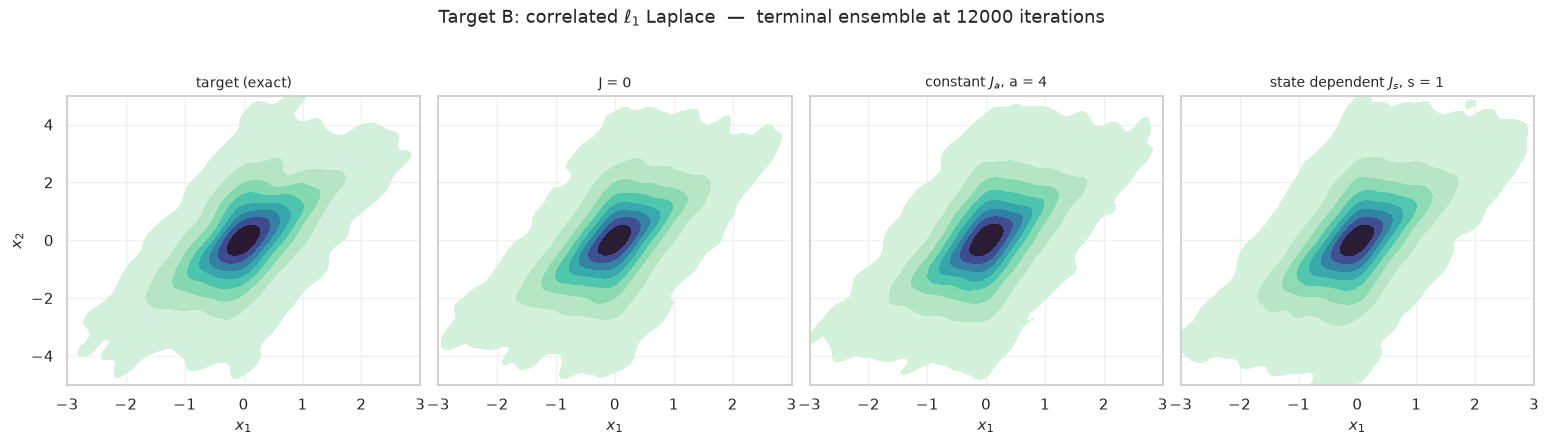

In [11]:
# terminal densities, dims 1 and 2
for kind in TARGETS:
    panels = [("target (exact)", refs[kind])] + [
        (lab, RES[kind][lab]["X"].reshape(-1, d)) for lab in MAIN]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.9 * len(panels), 4.3),
                             sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("$x_1$", fontsize=11)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-5, 5)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("$x_2$", fontsize=11)
    fig.suptitle(TARGETS[kind] + "  —  terminal ensemble at {} iterations".format(MAXIT),
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig("figures/mv_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Summary

Three families under the project's labels: **$J=0$**, **constant $J_a$** and **state dependent $J_s$**.
Unconstrained, every antisymmetric $J$ with $\nabla\!\cdot J=0$ leaves $\pi$ invariant, so the choice of
$J$ is purely a rate choice. The original notebook made that choice arbitrarily — a tridiagonal pattern
with no relation to $\Sigma$ — and read the result at a horizon where nothing had converged. Both are
fixed here, and the gain from the constant skew roughly doubles once it is aimed. The state dependent
field, which was the better choice on the ball, is the worst choice here.

### Mean Wasserstein

| target | scheme | $\tau$ | speed-up | stationary $W_1$ | vs floor |
|---|---|---|---|---|---|
| **A** | $J=0$ | 2462 [2388, 2550] | — | 0.0590 | 0.85× |
| A | constant $J_a$, $a=4$ | 1479 [1438, 1521] | 1.66× [1.59, 1.74] | 0.0688 | 0.99× |
| A | constant $J_a$, $a=8$ | 1333 [1262, 1408] | 1.85× [1.73, 1.97] | 0.1133 | 1.63× |
| A | constant $J_a$ aligned, $a=2$ | 1033 [1000, 1067] | 2.38× [2.28, 2.50] | 0.0578 | 0.83× |
| A | constant $J_a$ aligned, $a=4$ | 775 [746, 808] | 3.18× [3.02, 3.34] | 0.0673 | 0.97× |
| A | constant $J_a$ aligned, $a=8$ | 667 [654, 683] | **3.69× [3.55, 3.85]** | 0.0862 | 1.24× |
| A | constant $J_a$ anti-aligned, $a=4$ | 2229 [2100, 2362] | 1.10× [1.03, 1.19] | 0.0705 | 1.01× |
| A | state dependent $J_s$, $s=0.5$ | 2238 [2154, 2308] | 1.10× [1.05, 1.16] | 0.0647 | 0.93× |
| A | state dependent $J_s$, $s=1$ | 2062 [1950, 2167] | 1.19× [1.12, 1.28] | 0.0994 | 1.43× |
| A | state dependent $J_s$, $s=2$ | never | — | 0.4555 | 6.54× |
| A | state dependent $J_s$, $s=5$ | never | — | $1.5\times10^{3}$ | $2.2\times10^{4}$× |
| **B** | $J=0$ | 1633 [1550, 1712] | — | 0.0452 | 1.04× |
| B | constant $J_a$, $a=4$ | 1033 [967, 1096] | 1.58× [1.46, 1.72] | 0.0440 | 1.01× |
| B | constant $J_a$, $a=8$ | 2596 [958, 5767] | *not resolvable* | 0.0924 | 2.13× |
| B | constant $J_a$ aligned, $a=2$ | 662 [642, 683] | 2.47× [2.32, 2.61] | 0.0394 | 0.91× |
| B | constant $J_a$ aligned, $a=4$ | 479 [446, 517] | 3.41× [3.12, 3.73] | 0.0430 | 0.99× |
| B | constant $J_a$ aligned, $a=8$ | 358 [350, 367] | **4.56× [4.28, 4.82]** | 0.0465 | 1.07× |
| B | constant $J_a$ anti-aligned, $a=4$ | 1475 [1412, 1533] | 1.11× [1.04, 1.18] | 0.0527 | 1.21× |
| B | state dependent $J_s$, $s=0.5$ | 1533 [1467, 1600] | 1.07× [0.99, 1.14] | 0.0460 | 1.06× |
| B | state dependent $J_s$, $s=1$ | 1338 [1288, 1396] | *not resolvable* | 0.0872 | 2.01× |
| B | state dependent $J_s$, $s=2$ | never | — | 12.61 | 290× |
| B | state dependent $J_s$, $s=5$ | never (diverged at 10615) | — | $4.5\times10^{66}$ | $10^{68}$× |

**The state dependent $J_s$ does not carry over from the ball.** At $s=0.5$ it is indistinguishable from
$J=0$ (1.10× and 1.07×, the second interval touching 1). At $s=1$ it buys 1.19× and 1.22× but already sits
at 1.43× and 2.01× the floor, and at $s=2$ it has no stationary law within reach: 6.5× the floor on A and
290× on B. At $s=5$ the ensemble simply leaves: on A it ends at $\lVert x\rVert\sim10^{3}$ with $W_1$ four
orders of magnitude above the floor, and on B it overflows to non-finite values at iteration 10615 — the
chain is stopped there and $W_1$ reported up to that point. Since $\lVert J_s(x)\rVert_2=s\lVert x\rVert$, the field is strongest exactly on the walkers
furthest out, and without the ball there is no bound on how far out they get — the Euler step stops
resolving the drift in the tails long before the bulk feels any push. The constant $J_a$ at $a=4$ does
better than any usable $J_s$ on both speed and accuracy, and the aligned constant field better still.

**Aiming the constant skew is worth about a factor of two on top of the strength.** At the same $a=4$:
aligned 3.18× and 3.41×, tridiagonal 1.66× and 1.58×, anti-aligned 1.10× and 1.11× — the last is nothing,
on either target.
Same invariant law, same $\lVert J\rVert$, only the rotation plane differs.

**And aiming is what lets the strength be raised.** The aligned field improves monotonically to $a=8$
(3.69× and 4.56×), while the tridiagonal one stalls on A and becomes unmeasurable on B, where its
stationary $W_1$ is 2.13× the floor. A skew pointed in the wrong plane has to be pushed harder for the
same effect, and pushing it harder is what breaks the discretisation.

**At $a\le4$ the acceleration is free.** Aligned $a=2$ and $a=4$ sit at or below the floor on both targets
(0.83-0.99×), so 3.18× and 3.41× cost nothing measurable. Only $a=8$ starts to show a price (1.24× on A),
and $\eta$ would have to come down to spend it.

### Component-wise

The mean is dominated by coordinate 3, which has four times the variance of coordinate 1 and mixes
slowest — and that is where the aligned field does its work, because coordinate 3 is the direction the
rotation plane was chosen to contain. On coordinate 1 the schemes are nearly indistinguishable.

The per-coordinate view also catches something the mean hides: on Target B coordinate 2, the tridiagonal
field descends *fastest* early but then settles slightly **above** the floor, while the aligned runs sit on
it. Averaging over coordinates cancels that against its coordinate-3 deficit.

### A correction to the measurement itself

The first pass at this produced nonsense on Target B — every skew apparently *slower* than $J=0$, with
intervals like $\tau=3533$ [908, 6467]. The cause was the floor estimator, not the samplers.

The floor was estimated as $W_1$ between one fixed reference and a handful of fresh draws. That estimator
carries the particular reference's own deviation, and across independent estimates its spread is 15-20%
per coordinate — the mean over coordinates ranged over 1.9× on Target B (0.0329 to 0.0620). One low draw
put the $\tau$ threshold at $2\times0.0354=0.0708$, only 1.65× above the converged plateau of ~0.043, so
replica curves wandered back across it late in the run and the last-crossing statistic became a lottery.

Two changes fix it: draw **both** sides fresh for each of 24 pairs, which removes the conditioning and
brings the spread to a few percent; and put the $\tau$ threshold at $3\times$ the floor, clear of every
scheme's stationary noise. A guard now marks any row where a scheme's plateau is within 1.5× of the
threshold, so an unmeasurable $\tau$ is labelled rather than reported — it fires on constant $J_a$, $a=8$ on
Target B, on state dependent $J_s$, $s=1$ on Target B, and on $s=2$ and $s=5$ on both targets.

### Two things the original got wrong on its own terms

The prose said $\eta=5\times10^{-3}$ over 2000 iterations; the code ran $6\times10^{-3}$ for 1500. And at
1500 iterations $J=0$ sits at mean $W_1=0.33$ against a floor of 0.070 — five times above it and still
falling. Every reported number was a position in a race, not a stationary law. The settings now live in
one place and are printed, and the horizon is 12000, where $J=0$ genuinely reaches the floor.